# ReducedSymmetryP2P

Compares the normal P2P packing for each selected CPU or CUDA backend against the explicit `use_reduced_symmetry_p2p` Tensor6 dictionary plan. It reports stored tensors, P2P-plan memory, field agreement, and timed P2P runtime. CUDA timing uses the device P2P kernel time. This notebook is intentionally not executed during installation.

Select backends in `BACKENDS` and geometries in `GEOMETRIES`. CUDA point-dipole comparisons use BSR(3) as the baseline. Under the current `UniformFmm` policy, cuboid CUDA comparisons retain canonical AoS because cuboid self tensors are physical and the fixed-identity BSR selector is not active.


To build:


cmake --fresh --preset notebooks
cmake --build --preset notebooks -j
cmake --install build-notebooks

In [1]:
import cdfmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ORDER = 6
DEPTHS = (2, 3, 4)
GRID_SIDES = (8,10, 15, 20, 25, 30)#, 25)
WARMUPS = 2
TIMED_EVALUATIONS = 10
SPACING = 1.0
CUBOID_FILL = 1.0  # Cuboids touch: there is no gap.
CUDA_BSR_MAX_BYTES = 20 * 1024**3

BACKENDS = (
    #('cpu-static', cdfmm.ExecutionBackend.CPU_STATIC),
    ('cuda-full', cdfmm.ExecutionBackend.CUDA_FULL),
    # ('cuda-hybrid', cdfmm.ExecutionBackend.CUDA_M2L_P2P),
)
CUDA_BACKENDS = (cdfmm.ExecutionBackend.CUDA_FULL, cdfmm.ExecutionBackend.CUDA_M2L_P2P)

cube = cdfmm.CuboidSize(CUBOID_FILL * SPACING, CUBOID_FILL * SPACING, CUBOID_FILL * SPACING)
GEOMETRIES = (
    ('point-point', cdfmm.SourceGeometry.POINT_DIPOLE, cdfmm.TargetGeometry.POINT, [], []),
    #('cuboid-point', cdfmm.SourceGeometry.UNIFORM_CUBOID, cdfmm.TargetGeometry.POINT, [cube], []),
    #('cuboid-cuboid', cdfmm.SourceGeometry.UNIFORM_CUBOID, cdfmm.TargetGeometry.VOLUME_AVERAGED_CUBOID, [cube], [cube]),
)

In [2]:
def cartesian_centres(side):
    grid = np.indices((side, side, side), dtype=float).reshape(3, -1).T
    return (grid - (side - 1) / 2.0) * SPACING

def reduction_factor(canonical, reduced):
    return np.nan if reduced == 0 else canonical / reduced

def safe_ratio(numerator, denominator):
    return np.nan if denominator == 0 else numerator / denominator

def cuda_p2p_persistent_bytes(fmm):
    stats = fmm.cuda_plan_statistics
    return sum(stats[name] for name in (
        'p2p_tensor_bytes', 'p2p_index_bytes', 'p2p_row_metadata_bytes',
        'p2p_leaf_metadata_bytes', 'p2p_identity_bytes'))

def make_fmm(positions, backend, geometry, depth, reduced):
    _, backend_value = backend
    _, source_geometry, target_geometry, source_sizes, target_sizes = geometry
    options = cdfmm.UniformFmmOptions()
    options.precision = cdfmm.StaticPrecision.FLOAT32
    options.backend = backend_value
    options.expansion_order = ORDER
    options.tree.max_level = depth
    options.source_geometry, options.target_geometry = source_geometry, target_geometry
    options.source_sizes, options.target_sizes = source_sizes, target_sizes
    options.use_cuboid_p2m = options.use_cuboid_l2p = False
    options.fixed_target_source_indices = list(range(len(positions)))
    options.use_reduced_symmetry_p2p = reduced
    if backend_value in CUDA_BACKENDS:
        options.cuda_p2p_bsr_max_bytes = CUDA_BSR_MAX_BYTES
    return cdfmm.UniformFmm(positions, positions, options)

def run_case(backend, geometry, side, depth):
    backend_name, backend_value = backend
    if backend_value == cdfmm.ExecutionBackend.CUDA_FULL and not cdfmm.cuda_full_available():
        raise RuntimeError('CUDA_FULL is selected but is not available in this cdfmm build/runtime')
    if backend_value == cdfmm.ExecutionBackend.CUDA_M2L_P2P and not cdfmm.cuda_m2l_p2p_available():
        raise RuntimeError('CUDA_M2L_P2P is selected but is not available in this cdfmm build/runtime')
    positions = cartesian_centres(side)
    identities = np.arange(len(positions), dtype=np.int32)
    moments = np.random.default_rng(1000 + len(positions)).normal(size=(len(positions), 3))
    canonical = make_fmm(positions, backend, geometry, depth, reduced=False)
    reduced = make_fmm(positions, backend, geometry, depth, reduced=True)
    is_cuda = backend_value in CUDA_BACKENDS
    point_sources = geometry[1] == cdfmm.SourceGeometry.POINT_DIPOLE
    expected_canonical = (cdfmm.P2PExecutionPacking.CUDA_BSR3 if is_cuda and point_sources
                          else cdfmm.P2PExecutionPacking.CANONICAL_AOS if is_cuda
                          else cdfmm.P2PExecutionPacking.PARTICLE_ROW_SOA)
    if canonical.p2p_execution_packing != expected_canonical:
        raise RuntimeError(
            f'{backend_name} baseline resolved {canonical.p2p_execution_packing}; '
            f'expected {expected_canonical}'
        )
    if reduced.p2p_execution_packing != cdfmm.P2PExecutionPacking.TENSOR_DICTIONARY:
        raise RuntimeError(
            f'Reduced-symmetry P2P was not built (resolved {reduced.p2p_execution_packing}). '
            'Rebuild and reinstall cdfmm, then restart the notebook kernel.'
        )
    for fmm in (canonical, reduced):
        for _ in range(WARMUPS):
            fmm.evaluate(moments, target_source_indices=identities)
    timings = {}
    fields = {}
    timing_key = 'cuda_p2p_kernel' if is_cuda else 'p2p'
    for name, fmm in (('canonical', canonical), ('reduced', reduced)):
        samples = []
        for _ in range(TIMED_EVALUATIONS):
            fields[name] = fmm.evaluate(moments, target_source_indices=identities)['H']
            samples.append(1e3 * fmm.last_timings[timing_key])
        timings[name] = samples
    np.testing.assert_allclose(fields['reduced'], fields['canonical'], rtol=5e-5, atol=5e-6)
    difference = np.abs(fields['reduced'] - fields['canonical'])
    canonical_stats, reduced_stats = canonical.static_plan_statistics, reduced.static_plan_statistics
    if is_cuda:
        canonical_cuda, reduced_cuda = canonical.cuda_plan_statistics, reduced.cuda_plan_statistics
        canonical_tensor_bytes = canonical_cuda['p2p_tensor_bytes']
        reduced_tensor_bytes = reduced_cuda['p2p_tensor_bytes']
        canonical_plan_bytes = cuda_p2p_persistent_bytes(canonical)
        reduced_plan_bytes = cuda_p2p_persistent_bytes(reduced)
        reduced_token_bytes = reduced_cuda['p2p_index_bytes']
        memory_scope = 'cuda-device-p2p'
    else:
        canonical_tensor_bytes = canonical_stats['p2p_value_bytes']
        reduced_tensor_bytes = reduced_stats['p2p_dictionary_tensor_bytes']
        canonical_plan_bytes = canonical_stats['p2p_canonical_total_bytes']
        reduced_plan_bytes = reduced_stats['p2p_dictionary_total_bytes']
        reduced_token_bytes = reduced_stats['p2p_dictionary_token_bytes']
        memory_scope = 'host-execution-packing'
    return dict(backend=backend_name, baseline=str(expected_canonical), memory_scope=memory_scope,
                geometry=geometry[0], depth=depth, order=ORDER, grid_side=side, particles=len(positions),
                particles_per_leaf=len(positions) / (8**depth),
                baseline_tensors=canonical_stats['p2p_interactions'],
                reduced_tensors=reduced_stats['p2p_unique_tensors'],
                baseline_tensor_bytes=canonical_tensor_bytes,
                baseline_plan_bytes=canonical_plan_bytes,
                reduced_tensor_bytes=reduced_tensor_bytes,
                reduced_token_bytes=reduced_token_bytes,
                reduced_plan_bytes=reduced_plan_bytes,
                tensor_reduction_factor=reduction_factor(canonical_stats['p2p_interactions'], reduced_stats['p2p_unique_tensors']),
                plan_memory_reduction_factor=reduction_factor(canonical_plan_bytes, reduced_plan_bytes),
                p2p_ms_baseline=float(np.median(timings['canonical'])),
                p2p_ms_reduced=float(np.median(timings['reduced'])),
                p2p_speedup=float(safe_ratio(np.median(timings['canonical']), np.median(timings['reduced']))),
                max_abs_field_difference=float(difference.max()),
                max_relative_field_difference=float(difference.max() / max(np.abs(fields['canonical']).max(), np.finfo(float).tiny)))

In [3]:
rows = [run_case(backend, geometry, side, depth) for backend in BACKENDS for geometry in GEOMETRIES for depth in DEPTHS for side in GRID_SIDES]
results = pd.DataFrame(rows)
display(results)

[cdfmm] UniformFmm initialisation
  source_count: 512
  target_count: 512
  expansion_order: 6
  coefficient_count: 49
  expansion_basis: spherical
  precision: float32
  backend.requested: cuda_full
  backend.resolved: cuda_full
  m2l_backend.requested: static
  m2l_backend.resolved: static
  spherical_m2l_backend: static_dense
  static_matrix_backend: portable
  executor.p2m: cuda
  executor.m2m: cuda
  executor.m2l: cuda
  executor.l2l: cuda
  executor.l2p: cuda
  executor.p2p: cuda
  p2p_packing: cuda_bsr3
  p2p.signed_target_tile_size: 32
  p2p.signed_simd_path: avx2-gather-fma
  tree.max_level.requested: 2
  tree.max_level.resolved: 2
  tree.include_empty_nodes: true
  tree.cubic_root_box: true
  tree.root_centre.requested: auto
  tree.root_centre.physical_resolved: [0, 0, 0]
  tree.root_half_width.requested: auto
  tree.root_half_width.physical_resolved: 3.5
  tree.root_side_length.physical_resolved: 7
  tree.root_centre.internal: [0, 0, 0]
  tree.root_half_width.internal: 0.5
 

,backend,baseline,memory_scope,geometry,depth,order,grid_side,particles,particles_per_leaf,baseline_tensors,...,reduced_tensor_bytes,reduced_token_bytes,reduced_plan_bytes,tensor_reduction_factor,plan_memory_reduction_factor,p2p_ms_baseline,p2p_ms_reduced,p2p_speedup,max_abs_field_difference,max_relative_field_difference
0,cuda-full,P2PExecutionPacking.CUDA_BSR3,cuda-device-p2p,point-point,2,6,8,512,8.000000,64000,...,13104,128000,158388,117.216117,16.175796,0.022528,0.045056,0.500000,4.172325e-07,4.107710e-07
1,cuda-full,P2PExecutionPacking.CUDA_BSR3,cuda-device-p2p,point-point,2,6,10,1000,15.625000,195112,...,20376,390224,427884,229.813899,18.249068,0.032752,0.061440,0.533073,7.152557e-07,5.839603e-07
2,cuda-full,P2PExecutionPacking.CUDA_BSR3,cuda-device-p2p,point-point,2,6,15,3375,52.734375,2571353,...,118008,5142706,5277998,522.951597,19.489894,0.166752,0.406528,0.410186,1.430511e-06,1.167778e-06
3,cuda-full,P2PExecutionPacking.CUDA_BSR3,cuda-device-p2p,point-point,2,6,20,8000,125.000000,15625000,...,289200,31250000,31556484,1296.680498,19.806769,0.611248,4.251968,0.143756,3.397465e-06,2.697143e-06
4,cuda-full,P2PExecutionPacking.CUDA_BSR3,cuda-device-p2p,point-point,2,6,25,15625,244.140625,57066625,...,388056,114133250,114539182,3529.384934,19.929665,1.779408,2.222592,0.800600,4.172325e-06,3.364363e-06
5,cuda-full,P2PExecutionPacking.CUDA_BSR3,cuda-device-p2p,point-point,2,6,30,27000,421.875000,164566592,...,804864,329133184,329956804,4907.162214,19.950404,4.593120,23.565664,0.194907,5.364418e-06,3.823620e-06
6,cuda-full,P2PExecutionPacking.CUDA_BSR3,cuda-device-p2p,point-point,3,6,8,512,1.000000,10648,...,2544,10648,193804,100.452830,2.208272,0.012288,0.024368,0.504268,1.788139e-07,1.764170e-07
7,cuda-full,P2PExecutionPacking.CUDA_BSR3,cuda-device-p2p,point-point,3,6,10,1000,1.953125,32768,...,4128,32768,217508,190.511628,6.044486,0.014368,0.028672,0.501116,3.576279e-07,2.919887e-07
8,cuda-full,P2PExecutionPacking.CUDA_BSR3,cuda-device-p2p,point-point,3,6,15,3375,6.591797,456533,...,15552,913066,1109230,704.526235,16.475234,0.030720,0.047104,0.652174,5.960464e-07,4.865861e-07
9,cuda-full,P2PExecutionPacking.CUDA_BSR3,cuda-device-p2p,point-point,3,6,20,8000,15.625000,2299968,...,50136,4599936,4830684,1100.989947,19.051282,0.105472,0.081920,1.287500,8.344650e-07,6.627300e-07


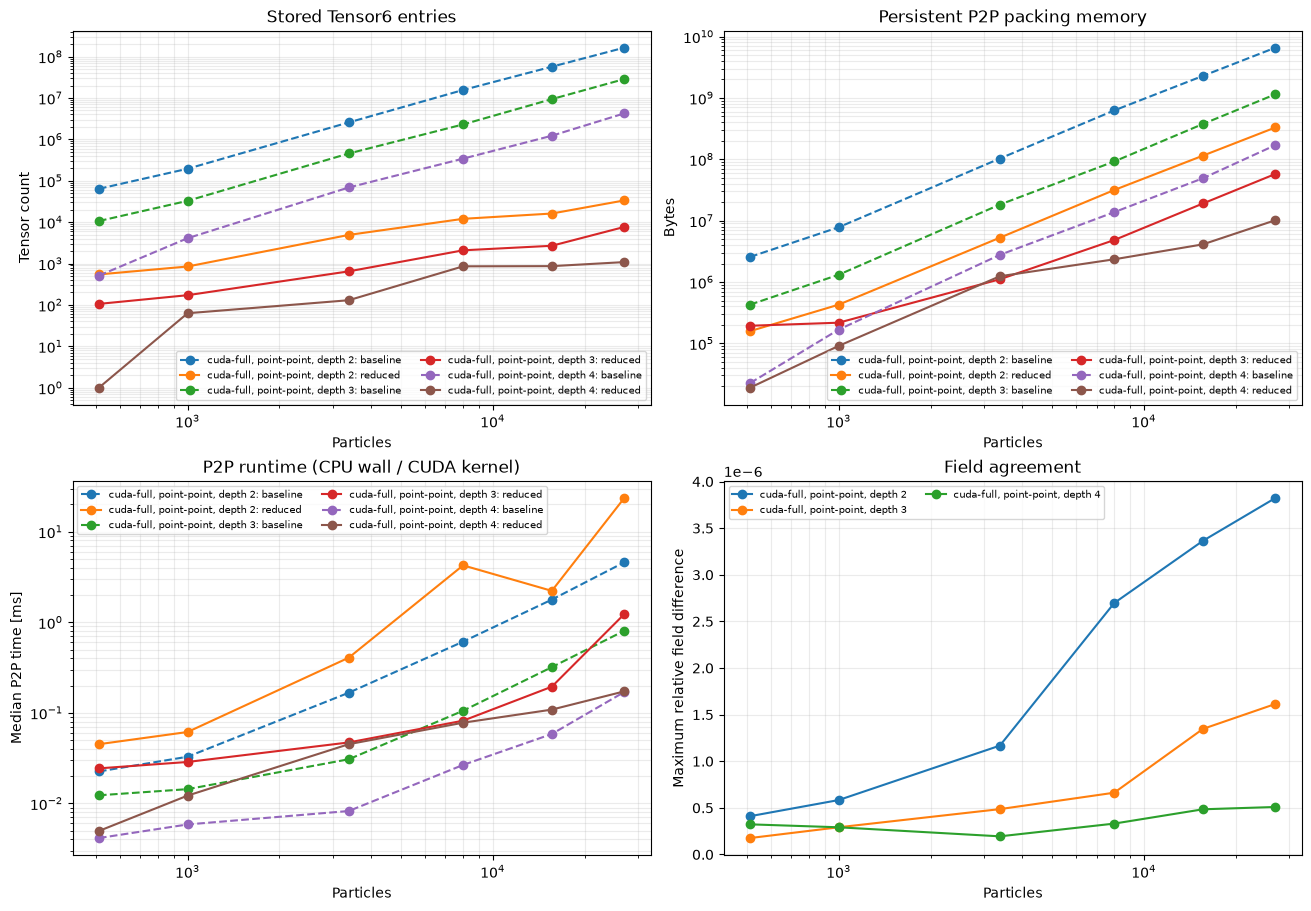

,backend,baseline,geometry,depth,particles,particles_per_leaf,tensor_reduction_factor,plan_memory_reduction_factor,p2p_speedup
0,cuda-full,P2PExecutionPacking.CUDA_BSR3,point-point,2,512,8.000000,117.216117,16.175796,0.500000
1,cuda-full,P2PExecutionPacking.CUDA_BSR3,point-point,2,1000,15.625000,229.813899,18.249068,0.533073
2,cuda-full,P2PExecutionPacking.CUDA_BSR3,point-point,2,3375,52.734375,522.951597,19.489894,0.410186
3,cuda-full,P2PExecutionPacking.CUDA_BSR3,point-point,2,8000,125.000000,1296.680498,19.806769,0.143756
4,cuda-full,P2PExecutionPacking.CUDA_BSR3,point-point,2,15625,244.140625,3529.384934,19.929665,0.800600
5,cuda-full,P2PExecutionPacking.CUDA_BSR3,point-point,2,27000,421.875000,4907.162214,19.950404,0.194907
6,cuda-full,P2PExecutionPacking.CUDA_BSR3,point-point,3,512,1.000000,100.452830,2.208272,0.504268
7,cuda-full,P2PExecutionPacking.CUDA_BSR3,point-point,3,1000,1.953125,190.511628,6.044486,0.501116
8,cuda-full,P2PExecutionPacking.CUDA_BSR3,point-point,3,3375,6.591797,704.526235,16.475234,0.652174
9,cuda-full,P2PExecutionPacking.CUDA_BSR3,point-point,3,8000,15.625000,1100.989947,19.051282,1.287500


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for (backend, geometry, depth), group in results.groupby(['backend', 'geometry', 'depth']):
    label = f'{backend}, {geometry}, depth {depth}'
    group = group.sort_values('particles')
    axes[0, 0].loglog(group['particles'], group['baseline_tensors'], 'o--', label=f'{label}: baseline')
    axes[0, 0].loglog(group['particles'], group['reduced_tensors'], 'o-', label=f'{label}: reduced')
    axes[0, 1].loglog(group['particles'], group['baseline_plan_bytes'], 'o--', label=f'{label}: baseline')
    axes[0, 1].loglog(group['particles'], group['reduced_plan_bytes'], 'o-', label=f'{label}: reduced')
    axes[1, 0].loglog(group['particles'], group['p2p_ms_baseline'], 'o--', label=f'{label}: baseline')
    axes[1, 0].loglog(group['particles'], group['p2p_ms_reduced'], 'o-', label=f'{label}: reduced')
    axes[1, 1].semilogx(group['particles'], group['max_relative_field_difference'], 'o-', label=label)

axes[0, 0].set(title='Stored Tensor6 entries', xlabel='Particles', ylabel='Tensor count')
axes[0, 1].set(title='Persistent P2P packing memory', xlabel='Particles', ylabel='Bytes')
axes[1, 0].set(title='P2P runtime (CPU wall / CUDA kernel)', xlabel='Particles', ylabel='Median P2P time [ms]')
axes[1, 1].set(title='Field agreement', xlabel='Particles', ylabel='Maximum relative field difference')
for axis in axes.flat:
    axis.grid(True, which='both', alpha=0.25)
    axis.legend(fontsize=7, ncol=2)
plt.show()

display(results[['backend', 'baseline', 'geometry', 'depth', 'particles', 'particles_per_leaf', 'tensor_reduction_factor', 'plan_memory_reduction_factor', 'p2p_speedup']])